In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
file_path = 'product_monthly_panel.csv'
product_df = pd.read_csv(file_path)

# Selecting numerical features for clustering & classification
numerical_cols = ['rating', 'helpfulness', 'total_feedback_count',
                  'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd']
target_col = 'Cluster'  # Cluster labels from K-Means



In [2]:
# Drop rows with missing values for clustering
product_numeric = product_df[numerical_cols].dropna().copy()

# Standardizing the features
scaler = StandardScaler()
product_scaled = scaler.fit_transform(product_numeric)

In [3]:
# Apply K-Means Clustering to generate cluster labels
optimal_clusters = 3  # Using k=3 as done in hierarchical clustering
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
product_numeric['Cluster'] = kmeans.fit_predict(product_scaled)

In [4]:
# Merge the cluster labels into product_df
product_df.loc[product_numeric.index, 'Cluster'] = product_numeric['Cluster']

# Verify that 'Cluster' is now in product_df
print("Updated columns in product_df:", product_df.columns)
print("Cluster value counts:\n", product_df['Cluster'].value_counts())

Updated columns in product_df: Index(['product_id', 'submission_time', 'rating', 'is_recommended',
       'helpfulness', 'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'price_usd', 'brand_name', 'skin_tone',
       'eye_color', 'skin_type', 'hair_color', 'Cluster'],
      dtype='object')
Cluster value counts:
 Cluster
0.0    49376
1.0    19315
2.0      780
Name: count, dtype: int64


In [5]:
# Drop rows with missing values for Decision Tree training
product_df = product_df[numerical_cols + [target_col]].dropna()


In [6]:
# Splitting features (X) and target (y)
X = product_df[numerical_cols]
y = product_df[target_col]

# Train-test split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [7]:
# Initialize and train Decision Tree Classifier
dtc = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dtc.fit(X_train, y_train)

# Make predictions
y_pred = dtc.predict(X_test)

In [8]:
# Evaluate the model
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


Confusion Matrix:
[[14510   298     5]
 [  503  5287     5]
 [   30     6   198]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.98      0.97     14813
         1.0       0.95      0.91      0.93      5795
         2.0       0.95      0.85      0.90       234

    accuracy                           0.96     20842
   macro avg       0.95      0.91      0.93     20842
weighted avg       0.96      0.96      0.96     20842

Accuracy: 95.94%


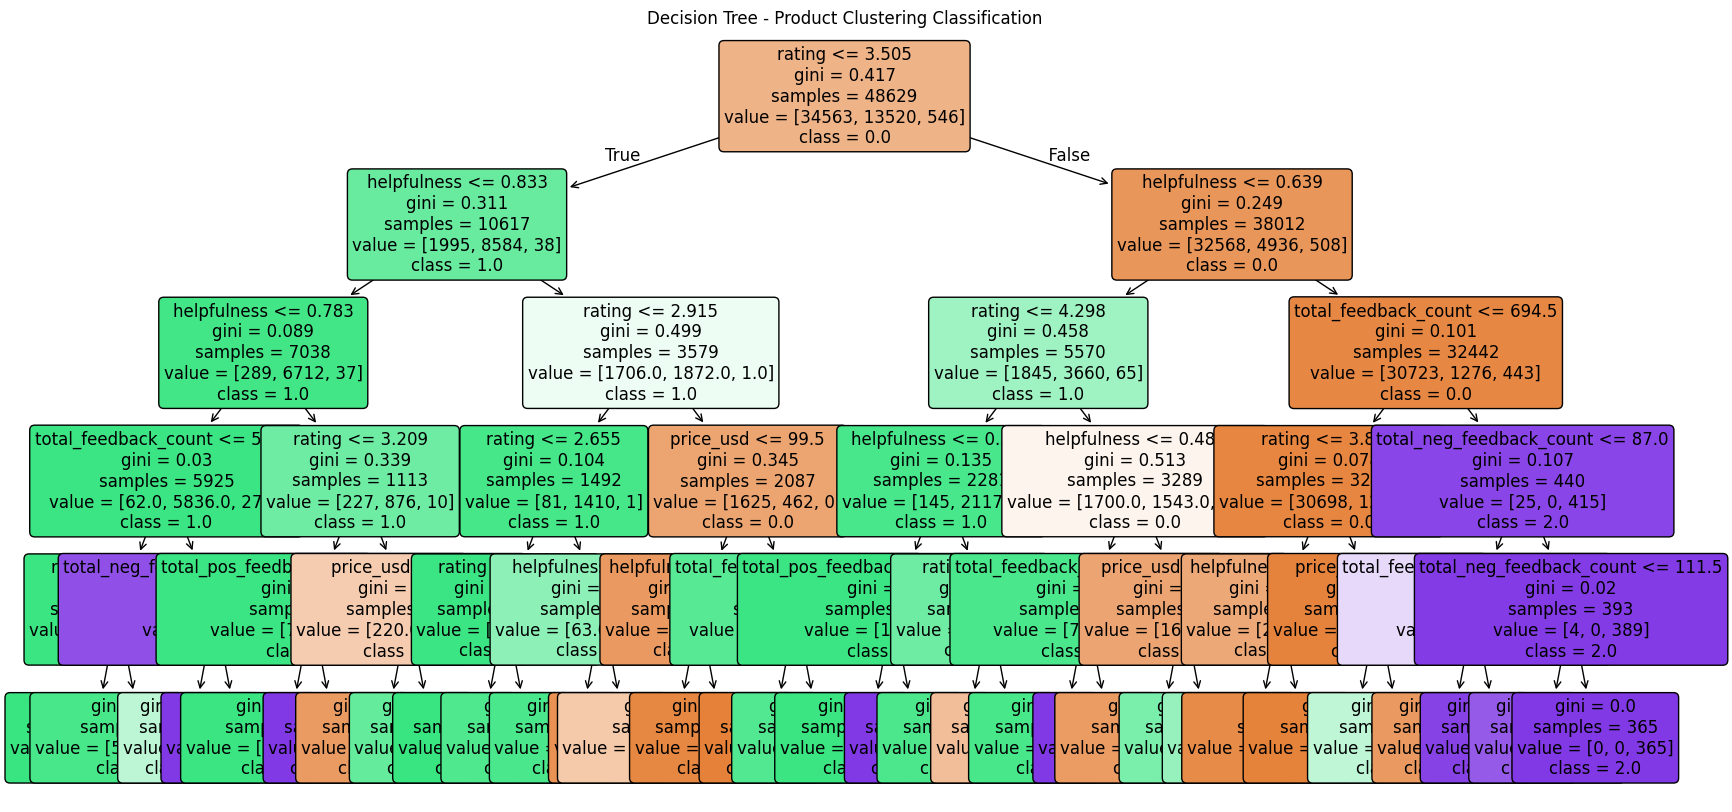

In [9]:
# Visualizing the Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dtc, feature_names=numerical_cols, class_names=[str(i) for i in sorted(y.unique())], filled=True, rounded=True, fontsize=12)
plt.title('Decision Tree - Product Clustering Classification')
plt.show()


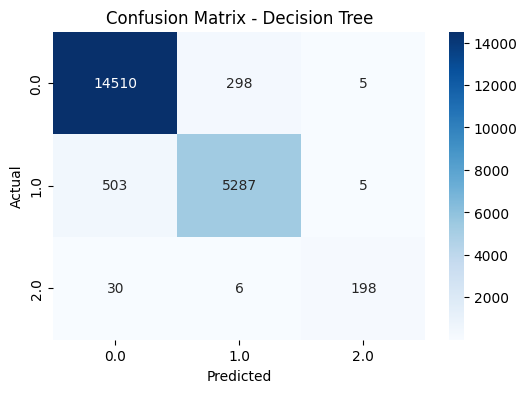

In [10]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Decision Tree')
plt.show()